In [23]:
import numpy as np
from matplotlib import pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
import menstrualmodel as mm

In [29]:
c1, c2, c3, c4, c5 = 0.1, 0.1, 0.01, 0.1, 0.1
b1, b2 = .1, .1

constants = c1, c2, c3, c4, c5

# Define other constants.
G0, L0, E0 = 1.0, .25, 1.0
n = 2000
t_f = 3*28

initial_conditions = {
    'GnRH': 1.0,
    'LH': 0.25,
    'Estrogen': 1.0
    }


model = mm.ControlMenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 3*28), resolution=1000)
# sol = model.simulate([0, 0, 0])
# model.plot(sol, plot_day_14=True, ylim=(0, 12), title="Best Fit Model")
# plt.show()

In [30]:
# Initialize state, costate, and u.
state0 = np.array([G0, L0, E0])
costate0 = np.zeros(3)

u = np.zeros((3, n))
u[0], u[1] = b1, b2

max_step = 0.5

epsilon = 0.001
test = epsilon + 1

tls = np.linspace(0, t_f, n)
while(test > epsilon):
    oldu = u.copy()
    u_interpolation = CubicSpline(tls, oldu, axis=1)

    # Solve the state equations forward in time.
    state_solution = solve_ivp(
        model.ode, 
        t_span=(0, t_f), 
        y0=state0, 
        method='RK45',
        t_eval=tls,
        args=(u_interpolation,),
        dense_output=True,
        max_step=max_step
        )

    # Solve the costate equations backward in time.
    costate_solution = solve_ivp(
        model.costate_equations,
        t_span=(t_f, 0),
        y0=costate0,
        method='RK45',
        t_eval=tls[::-1],
        args=(u_interpolation, state_solution, constants),
        dense_output=True,
        max_step=max_step
        )

    # Solve for u1 and u2.
    G, L, E = state_solution.y
    lam1, lam2, lam3 = np.array(costate_solution.y)[:, ::-1]

    umax = 1
    umin = -1
    uG = np.clip(lam1 / (2 * c3), -umin, umax)
    uL = np.clip(lam2 / (2 * c5), -umin, umax)
    uE = np.clip(lam3 / (2 * c4), -umin, umax)
    
    # Update control u with u1 and u2.
    u = np.array([uG, uL, uE])

    # Test for convergence
    test = abs(oldu - u).sum()

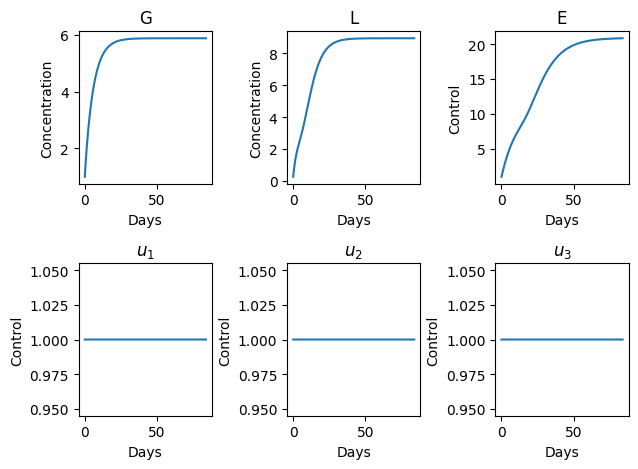

In [31]:
plt.subplot(2, 3, 1)
plt.plot(tls, G)
plt.xlabel('Days')
plt.ylabel('Concentration')
plt.title('G')

plt.subplot(2, 3, 2)
plt.plot(tls, L)
plt.xlabel('Days')
plt.ylabel('Concentration')
plt.title('L')

plt.subplot(2, 3, 3)
plt.plot(tls, E)
plt.xlabel('Days')
plt.ylabel('Control')
plt.title('E')

plt.subplot(2, 3, 4)
plt.plot(tls, uG)
plt.xlabel('Days')
plt.ylabel('Control')
plt.title(r'$u_1$')

plt.subplot(2, 3, 5)
plt.plot(tls, uL)
plt.xlabel('Days')
plt.ylabel('Control')
plt.title(r'$u_2$')

plt.subplot(2, 3, 6)
plt.plot(tls, uE)
plt.xlabel('Days')
plt.ylabel('Control')
plt.title(r'$u_3$')

plt.tight_layout()
